In [1]:
from sklearn.datasets import make_regression
from helpers import *
from filters import *
from functools import partial


In [2]:
import numpy as np
preds = np.load('./preds_mcd_af.npy')
gts = np.load('./gts_mcd_af.npy')

gts_nAF = 1-gts
gts_AF = gts
preds_nAF = preds[:,0]
preds_AF = preds[:,1]

In [3]:
test_preds = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/test_preds/preds_mcd_af.npy')
test_gts = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/test_preds/gts_mcd_af.npy')

In [4]:
test_noise_preds = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/noise_preds/preds_mcd_af.npy')
test_noise_gts = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/noise_preds/gts_mcd_af.npy')

In [5]:
test_preds_AF = test_preds[:,1]
intervals = []
for i,pred in enumerate(test_preds_AF):
    #print(i/15377)
    intervals.append(predict_interval(pred,preds_AF,gts_AF))

In [6]:
test_noise_preds_AF = test_noise_preds[:,1]
intervals_noise = []
for i,pred in enumerate(test_noise_preds_AF):
    #print(i/15377)
    intervals_noise.append(predict_interval(pred,preds_AF,gts_AF))

# Threshold 0.5

## Retain only

### Original test set

/tmp/ipykernel_4172555/3449368603.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_4172555/3449368603.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_4172555/3449368603.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_4172555/3449368603.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.1115$
AURC cost-aware rule: 0.1194

AUCC naive rule:      593.1815$
AUCC cost-aware rule: 560.6090$


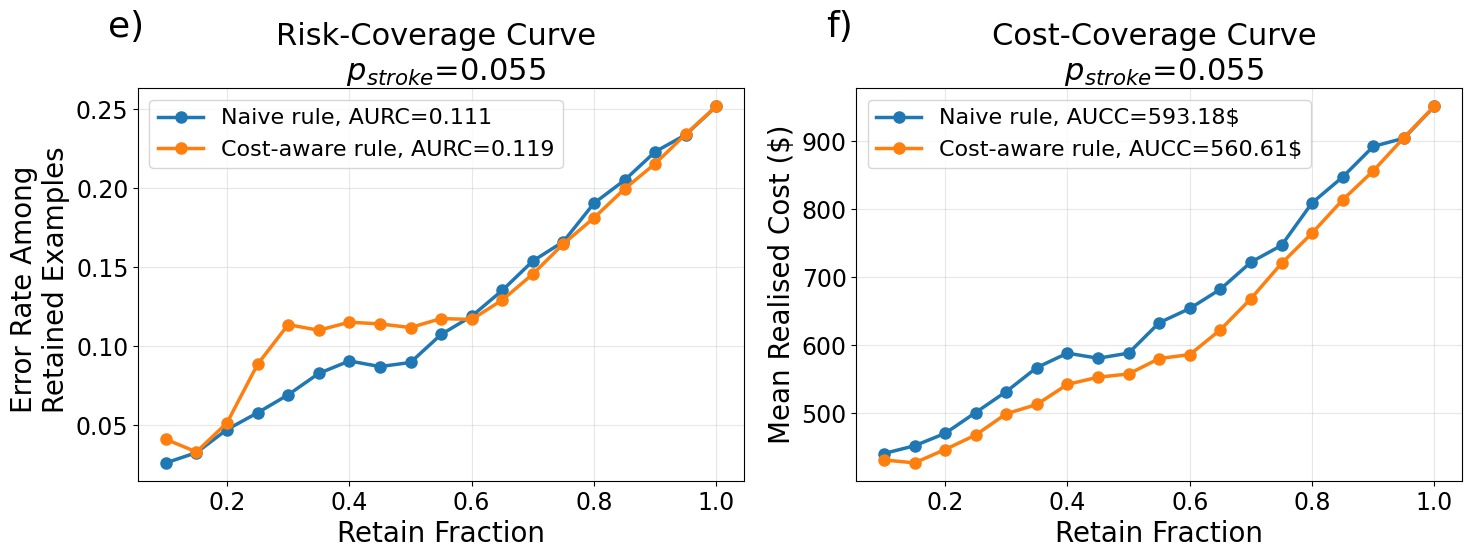

In [7]:
# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.055,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        cost_fn=cost_fn,
        threshold=0.5,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.5).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.055,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}$")
print(f"AURC cost-aware rule: {aurc_ec:.4f}")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction", fontsize=20)
axes[0].set_ylabel("Error Rate Among \n Retained Examples", fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.055", fontsize=22)
axes[0].tick_params(axis="both", labelsize=17)
axes[0].legend(fontsize=16)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction", fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)", fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.055", fontsize=22)
axes[1].tick_params(axis="both", labelsize=17)
axes[1].legend(fontsize=16)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Original Test Set", fontsize=26, y=.9)

axes[0].text(
    -0.05, 1.2, "e)",
    transform=axes[0].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)

axes[1].text(
    -0.05, 1.2, "f)",
    transform=axes[1].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)
# Leave room for suptitle
plt.tight_layout()
#fig.savefig("risk_cost_coverage_original_test_set_55.pdf", format="pdf", bbox_inches="tight")



plt.show()

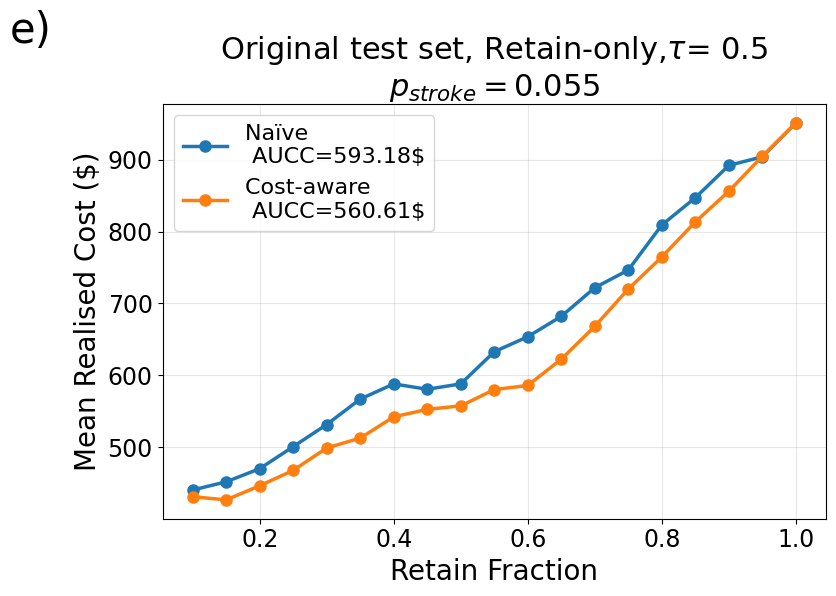

In [8]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title("Original test set, Retain-only," + r'$\tau$' + "= 0.5\n$p_{stroke}=0.055$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "e)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "cost_coverage_original_test_set_55.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

### augmented test set

/tmp/ipykernel_4172555/2363499734.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_4172555/2363499734.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_4172555/2363499734.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_4172555/2363499734.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.4197
AURC cost-aware rule: 0.4499

AUCC naive rule:      796.2983$
AUCC cost-aware rule: 756.5807$


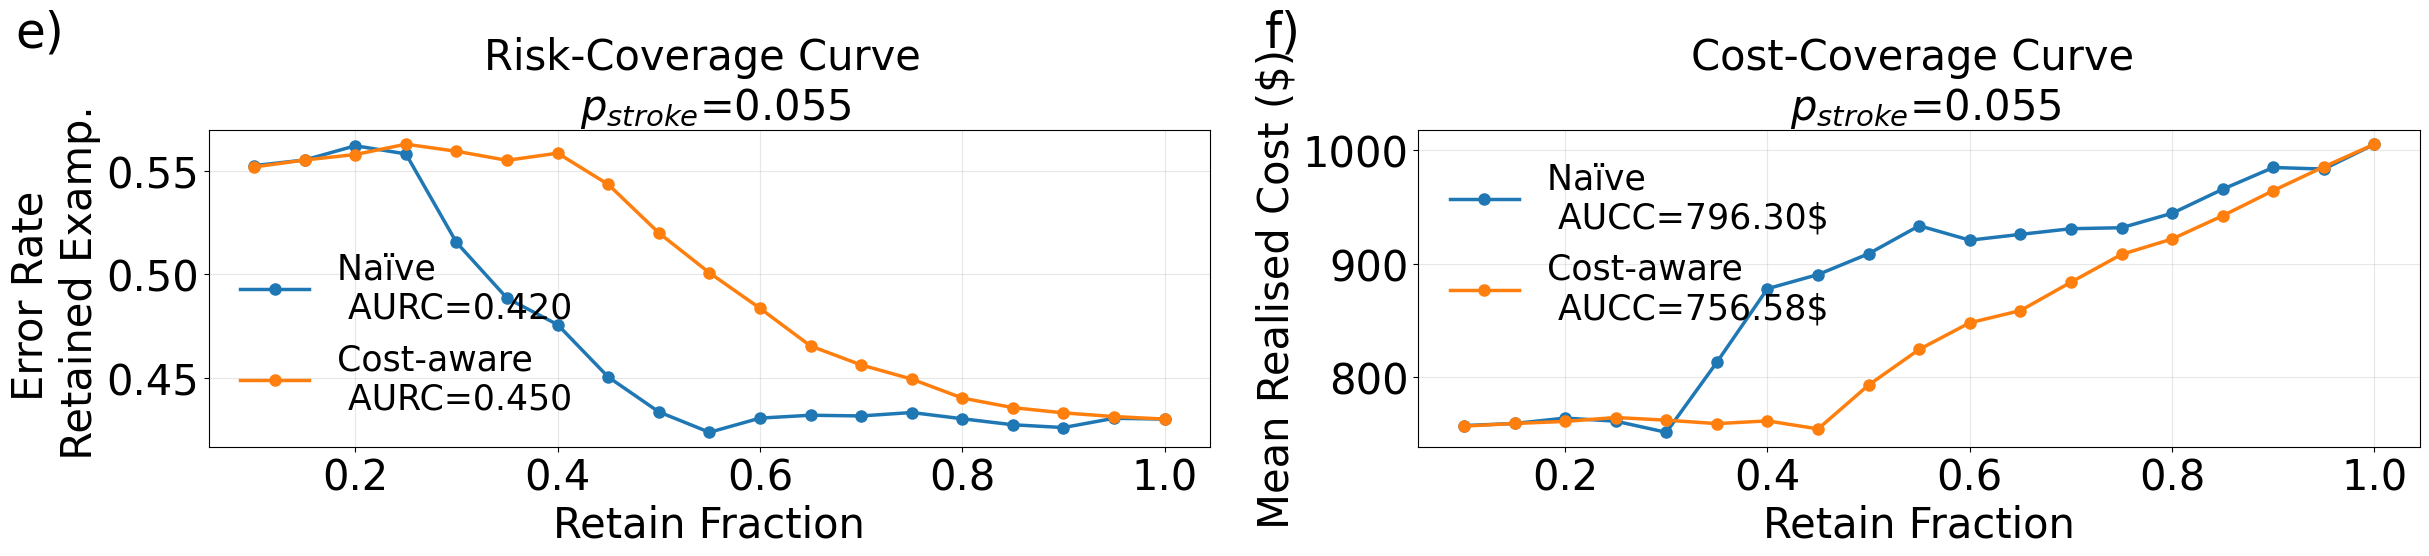

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.055,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        cost_fn=cost_fn,
        threshold=0.5,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.5).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.055,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}")
print(f"AURC cost-aware rule: {aurc_ec:.4f}")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "figure.titlesize": 30,
})

fig, axes = plt.subplots(1, 2, figsize=(25, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction")#, fontsize=20)
axes[0].set_ylabel("Error Rate \n Retained Examp.")#, fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.055")#, fontsize=22)
axes[0].tick_params(axis="both")#, labelsize=17)
axes[0].legend(fontsize=35)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction")#, fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)")#, fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.055")#, fontsize=22)
axes[1].tick_params(axis="both")#, labelsize=17)
axes[1].legend(fontsize=30)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Augmented Test Set", fontsize=35, y=.9, x=.43)

fig.text(
    0.02, 0.97, "e)",
    #transform=axes[0].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

fig.text(
    0.52, 0.97, "f)",
    #transform=axes[1].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

axes[0].legend(
    fontsize=25,
    loc="lower left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

axes[1].legend(
    fontsize=25,
    loc="upper left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
# Leave room for suptitle
# Leave room for suptitle
plt.tight_layout()
#fig.savefig("./risk_cost_coverage_augmented_test_set_55.pdf", format="pdf", bbox_inches="tight")
plt.show()

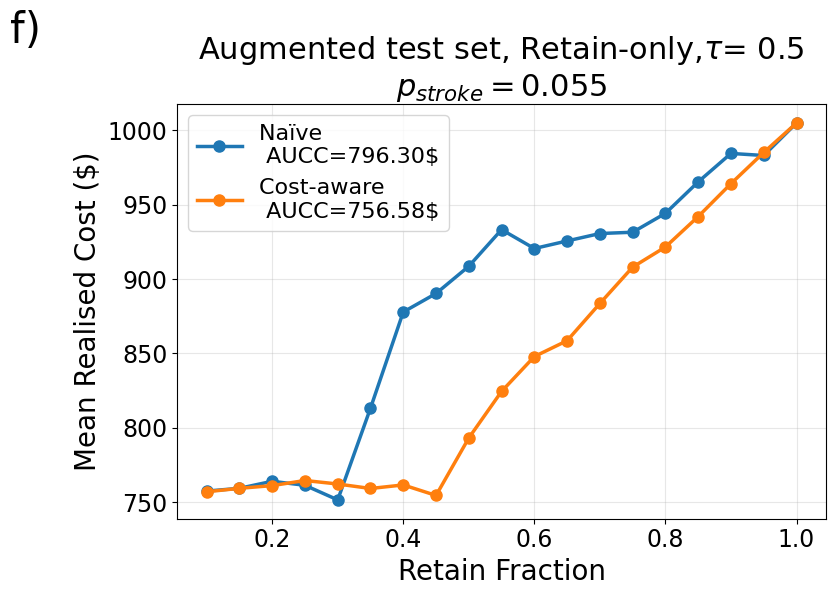

In [10]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title("Augmented test set, Retain-only," + r'$\tau$' + "= 0.5\n$p_{stroke}=0.055$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "f)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "cost_coverage_augmented_test_set_55.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## ECE 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss, log_loss


def evaluate_venn_abers_both_classes(
    intervals,
    y_true,
    n_bins=10,
    plot=True,
    ax=None,
):
    """
    Evaluate binary Venn-Abers predictions using collapsed probabilities
    for both classes and optionally draw a reliability diagram.

    Parameters
    ----------
    intervals : array-like of shape (n_samples, 2)
        Rows are [p0, p1], where:
            p0 = VA probability under assumed label 0
            p1 = VA probability under assumed label 1

    y_true : array-like of shape (n_samples,)
        Binary labels in {0,1}

    n_bins : int, default=10
        Number of quantile bins.

    plot : bool, default=True
        Whether to produce a reliability diagram.

    ax : matplotlib axis, optional
        Existing axis.

    Returns
    -------
    dict
    """

    # -----------------------------
    # 1) Input cleaning
    # -----------------------------
    intervals = np.asarray(intervals, dtype=float)
    y_true = np.asarray(y_true, dtype=int).reshape(-1)

    if intervals.ndim != 2 or intervals.shape[1] != 2:
        raise ValueError(
            "intervals must have shape (n_samples, 2)"
        )

    if len(intervals) != len(y_true):
        raise ValueError(
            "intervals and y_true must have same length"
        )

    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0/1 labels")

    # -----------------------------
    # 2) Venn-Abers collapse
    # -----------------------------
    p0 = np.minimum(intervals[:, 0], intervals[:, 1])
    p1 = np.maximum(intervals[:, 0], intervals[:, 1])

    width = p1 - p0

    denom = np.maximum(1.0 - p0 + p1, 1e-15)

    p_pos = p1 / denom
    p_pos = np.clip(p_pos, 1e-15, 1 - 1e-15)

    p_neg = 1.0 - p_pos

    # -----------------------------
    # 3) Global summaries
    # -----------------------------
    prevalence_pos = float(np.mean(y_true))
    prevalence_neg = float(1.0 - prevalence_pos)

    sharpness = {
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
        "p90_width": float(np.quantile(width, 0.90)),
        "max_width": float(np.max(width)),
    }

    # -----------------------------
    # 4) Scoring metrics
    # -----------------------------
    brier = float(
        brier_score_loss(y_true, p_pos)
    )

    ll = float(
        log_loss(y_true, p_pos, labels=[0, 1])
    )

    # -----------------------------
    # 5) Reliability bins
    # -----------------------------
    quantiles = np.linspace(0, 1, n_bins + 1)

    edges = np.quantile(p_pos, quantiles)
    edges[0] = -np.inf
    edges[-1] = np.inf

    bin_ids = np.digitize(
        p_pos,
        edges[1:-1],
        right=True
    )

    reliability_rows = []

    ece_pos = 0.0
    ece_neg = 0.0

    for b in range(n_bins):

        idx = np.where(bin_ids == b)[0]

        if len(idx) == 0:
            continue

        yt = y_true[idx]

        emp_pos = float(np.mean(yt))
        emp_neg = float(1.0 - emp_pos)

        avg_p_pos = float(np.mean(p_pos[idx]))
        avg_p_neg = float(np.mean(p_neg[idx]))

        weight = len(idx) / len(y_true)

        ece_pos += weight * abs(
            emp_pos - avg_p_pos
        )

        ece_neg += weight * abs(
            emp_neg - avg_p_neg
        )

        reliability_rows.append(
            {
                "bin": int(b),
                "count": int(len(idx)),
                "empirical_rate_pos": emp_pos,
                "empirical_rate_neg": emp_neg,
                "avg_collapsed_p_pos": avg_p_pos,
                "avg_collapsed_p_neg": avg_p_neg,
            }
        )

    collapsed_metrics = {
        "brier_score": brier,
        "log_loss": ll,
        "ece_pos": float(ece_pos),
        "ece_neg": float(ece_neg),
    }

    # -----------------------------
    # 6) Reliability diagram
    # -----------------------------
    fig = None

    if plot:

        if ax is None:
            fig, ax = plt.subplots(
                figsize=(7, 7)
            )
        else:
            fig = ax.figure

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            color="gray",
            label="Perfect calibration",
        )

        # Class 1
        x_pos = [
            row["avg_collapsed_p_pos"]
            for row in reliability_rows
        ]

        y_pos = [
            row["empirical_rate_pos"]
            for row in reliability_rows
        ]

        ax.plot(
            x_pos,
            y_pos,
            marker="o",
            linewidth=2,
            label=f"Class 1 (ECE={ece_pos:.3f})",
        )

        # Class 0
        x_neg = [
            row["avg_collapsed_p_neg"]
            for row in reliability_rows
        ]

        y_neg = [
            row["empirical_rate_neg"]
            for row in reliability_rows
        ]

        ax.plot(
            x_neg,
            y_neg,
            marker="^",
            linewidth=2,
            label=f"Class 0 (ECE={ece_neg:.3f})",
        )

        ax.set_title("Reliability Diagram \n $p_{stroke}$ = .055")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Empirical class frequency")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.text(-0.1, 1.15, "c)", transform=ax.transAxes, fontsize=30,  va="top")

        fig.tight_layout()

        fig.savefig(
            "ence_reliability_diagram_55.pdf",
            format="pdf",
            bbox_inches="tight",
        )

    # -----------------------------
    # 7) Return
    # -----------------------------
    results = {
        "global": {
            "prevalence_pos": prevalence_pos,
            "prevalence_neg": prevalence_neg,
        },
        "sharpness": sharpness,
        "collapsed_metrics": collapsed_metrics,
        "reliability_table": reliability_rows,
        "arrays": {
            "p0": p0,
            "p1": p1,
            "p_pos": p_pos,
            "p_neg": p_neg,
            "width": width,
        },
        "figure": fig,
        "axis": ax if plot else None,
    }

    return results

{'global': {'prevalence_pos': 0.37699161084736943,
  'prevalence_neg': 0.6230083891526306},
 'sharpness': {'mean_width': 0.003282052905158196,
  'median_width': 0.001773059368133545,
  'p90_width': 0.005613476037979126,
  'max_width': 0.13694489002227783},
 'collapsed_metrics': {'brier_score': 0.16128883730284127,
  'log_loss': 0.4894295091840286,
  'ece_pos': 0.07703206432584175,
  'ece_neg': 0.0770320643258417},
 'reliability_table': [{'bin': 0,
   'count': 1538,
   'empirical_rate_pos': 0.044213263979193757,
   'empirical_rate_neg': 0.9557867360208062,
   'avg_collapsed_p_pos': 0.06707418058673627,
   'avg_collapsed_p_neg': 0.9329258194132638},
  {'bin': 1,
   'count': 1590,
   'empirical_rate_pos': 0.12012578616352201,
   'empirical_rate_neg': 0.879874213836478,
   'avg_collapsed_p_pos': 0.15856388015424475,
   'avg_collapsed_p_neg': 0.8414361198457554},
  {'bin': 2,
   'count': 3046,
   'empirical_rate_pos': 0.10965200262639527,
   'empirical_rate_neg': 0.8903479973736047,
   'avg

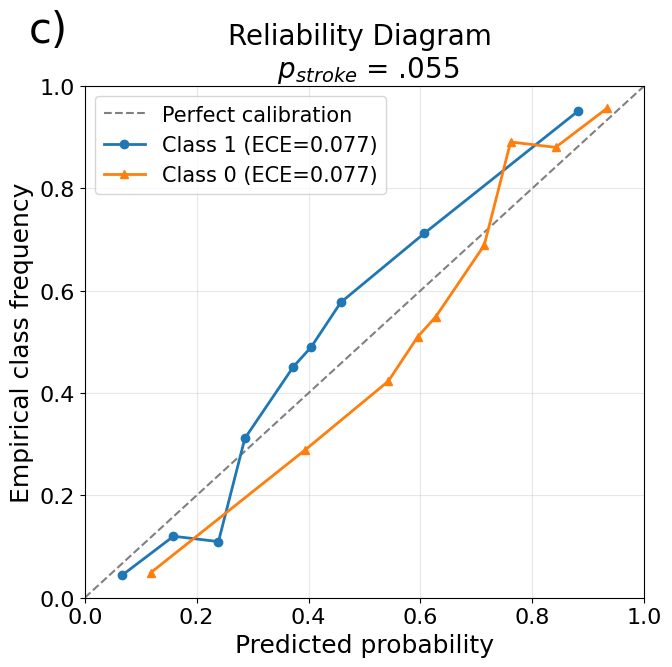

In [12]:
evaluate_venn_abers_both_classes(np.squeeze(intervals),test_gts)

{'global': {'prevalence_pos': 0.37699161084736943,
  'prevalence_neg': 0.6230083891526306},
 'sharpness': {'mean_width': 0.0038170358627005454,
  'median_width': 0.002673804759979248,
  'p90_width': 0.008461415767669678,
  'max_width': 0.13694489002227783},
 'collapsed_metrics': {'brier_score': 0.29977468381800415,
  'log_loss': 0.8730339257566414,
  'ece_pos': 0.18630592104461083,
  'ece_neg': 0.18630592104461083},
 'reliability_table': [{'bin': 0,
   'count': 2988,
   'empirical_rate_pos': 0.2784471218206158,
   'empirical_rate_neg': 0.7215528781793842,
   'avg_collapsed_p_pos': 0.23882736114649872,
   'avg_collapsed_p_neg': 0.7611726388535013},
  {'bin': 1,
   'count': 672,
   'empirical_rate_pos': 0.2976190476190476,
   'empirical_rate_neg': 0.7023809523809523,
   'avg_collapsed_p_pos': 0.254958608133025,
   'avg_collapsed_p_neg': 0.7450413918669748},
  {'bin': 2,
   'count': 992,
   'empirical_rate_pos': 0.3346774193548387,
   'empirical_rate_neg': 0.6653225806451613,
   'avg_coll

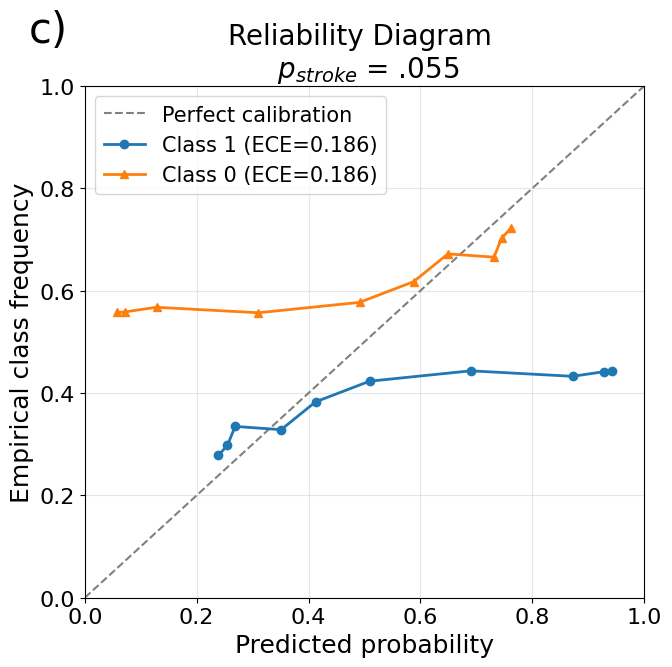

In [13]:
evaluate_venn_abers_both_classes(np.squeeze(intervals_noise),test_noise_gts)

# error composition

In [14]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)

def print_confusion_percentages(out, subset,tag):
    tp = out[subset]["tp"]
    fp = out[subset]["fp"]
    tn = out[subset]["tn"]
    fn = out[subset]["fn"]

    total = tp + fp + tn + fn

    print(f"\n{subset.upper()}")
    print(f"\n{tag.upper()}")
    print("-" * 30)
    print(f"Total: {total}")

    if total == 0:
        print("No examples in this subset.")
        return
    
    print(f"TP: {tp} ({100 * tp / total:.2f}%)")
    print(f"FP: {fp} ({100 * fp / total:.2f}%)")
    print(f"TN: {tn} ({100 * tn / total:.2f}%)")
    print(f"FN: {fn} ({100 * fn / total:.2f}%)")


print_confusion_percentages(out_mag_filtered, "overall",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "rejected",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "retained",'Prob retained noisy')


OVERALL

PROB FILTER NOISY
------------------------------
Total: 15377
TP: 2930 (19.05%)
FP: 3746 (24.36%)
TN: 5834 (37.94%)
FN: 2867 (18.64%)

REJECTED

PROB FILTER NOISY
------------------------------
Total: 7689
TP: 1114 (14.49%)
FP: 1420 (18.47%)
TN: 3295 (42.85%)
FN: 1860 (24.19%)

RETAINED

PROB RETAINED NOISY
------------------------------
Total: 7688
TP: 1816 (23.62%)
FP: 2326 (30.25%)
TN: 2539 (33.03%)
FN: 1007 (13.10%)


In [15]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    cost_fn=cost_fn,
    threshold=0.5,
    reject_fraction=0.5,
    pred_method="collapse",
)



print_confusion_percentages(out_ec_filtered, "overall",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "retained",'ec retained noisy')


OVERALL

EC FILTERED NOISY
------------------------------
Total: 15377
TP: 2930 (19.05%)
FP: 3746 (24.36%)
TN: 5834 (37.94%)
FN: 2867 (18.64%)

REJECTED

EC FILTERED NOISY
------------------------------
Total: 7689
TP: 0 (0.00%)
FP: 0 (0.00%)
TN: 5073 (65.98%)
FN: 2616 (34.02%)

RETAINED

EC RETAINED NOISY
------------------------------
Total: 7688
TP: 2930 (38.11%)
FP: 3746 (48.73%)
TN: 761 (9.90%)
FN: 251 (3.26%)


In [16]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    cost_fn=cost_fn,
    threshold=0.5,
    reject_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_ec_filtered, "overall",'ec filtered clean')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered clean')


OVERALL

EC FILTERED CLEAN
------------------------------
Total: 15377
TP: 2333 (15.17%)
FP: 409 (2.66%)
TN: 9171 (59.64%)
FN: 3464 (22.53%)

REJECTED

EC FILTERED CLEAN
------------------------------
Total: 7689
TP: 0 (0.00%)
FP: 0 (0.00%)
TN: 4675 (60.80%)
FN: 3014 (39.20%)


In [17]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_mag_filtered, "overall",'prob filtered clean')
print_confusion_percentages(out_mag_filtered, "rejected",'prob filtered clean')


OVERALL

PROB FILTERED CLEAN
------------------------------
Total: 15377
TP: 2333 (15.17%)
FP: 409 (2.66%)
TN: 9171 (59.64%)
FN: 3464 (22.53%)

REJECTED

PROB FILTERED CLEAN
------------------------------
Total: 7689
TP: 1097 (14.27%)
FP: 368 (4.79%)
TN: 3408 (44.32%)
FN: 2816 (36.62%)


In [18]:
# ============================================================
# Empirical paired bootstrap of AUCC
# ============================================================

import numpy as np
from functools import partial
from tqdm.auto import tqdm

N_BOOT = 1000
BOOT_SEED = 20250822
CI_LEVEL = 0.95
BOOT_RETAIN_FRACTIONS = np.linspace(0.1, 1.0, 19)


def _trapz(y, x):
    """Compatible with older and newer NumPy versions."""
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


def calculate_aucc(interval_array, y_true):
    """Recalculate naive and cost-aware AUCC for one empirical sample."""

    interval_array = np.asarray(interval_array)
    y_true = np.asarray(y_true).astype(int).reshape(-1)

    if interval_array.shape[0] != y_true.size:
        raise ValueError(
            "interval_array and y_true must contain the same number "
            "of observations."
        )

    naive_costs = []
    cost_aware_costs = []

    cost_fn = partial(
        compute_single_prediction_cost,
        p_stroke_missed_af=0.055,
    )

    for retain_fraction in BOOT_RETAIN_FRACTIONS:

        # Naive probability-magnitude filtering
        out_naive = evaluate_va_prob_magnitude_filtering(
            intervals=np.squeeze(interval_array),
            y_true=y_true,
            retain_fraction=retain_fraction,
            pred_method="collapse",
        )

        p_naive = np.asarray(
            out_naive["arrays"]["retained_p_hat"]
        )
        y_naive = np.asarray(
            out_naive["arrays"]["retained_y_true"]
        ).astype(int)

        naive_cost = compute_af_screening_cost(
            preds_AF,
            gts_AF,
            p_naive,
            y_naive,
            p_stroke_missed_af=0.055,
        )["expected_cost"]

        naive_costs.append(naive_cost)

        # Cost-aware expected-cost filtering
        out_cost_aware = evaluate_va_expected_cost_filtering(
            intervals=np.squeeze(interval_array),
            y_true=y_true,
            cost_fn=cost_fn,
            threshold=0.5,
            reject_fraction=1.0 - retain_fraction,
            pred_method="collapse",
        )

        p_cost_aware = np.asarray(
            out_cost_aware["arrays"]["retained_p_hat"]
        )
        y_cost_aware = np.asarray(
            out_cost_aware["arrays"]["retained_y_true"]
        ).astype(int)

        cost_aware_cost = compute_af_screening_cost(
            preds_AF,
            gts_AF,
            p_cost_aware,
            y_cost_aware,
            p_stroke_missed_af=0.055,
            threshold=0.5,
        )["expected_cost"]

        cost_aware_costs.append(cost_aware_cost)

    naive_aucc = _trapz(
        np.asarray(naive_costs),
        BOOT_RETAIN_FRACTIONS,
    )

    cost_aware_aucc = _trapz(
        np.asarray(cost_aware_costs),
        BOOT_RETAIN_FRACTIONS,
    )

    return naive_aucc, cost_aware_aucc


def bootstrap_aucc(
    interval_array,
    y_true,
    n_boot=N_BOOT,
    seed=BOOT_SEED,
    description="Bootstrapping AUCC",
):
    """Perform a paired non-parametric bootstrap of AUCC."""

    interval_array = np.asarray(interval_array)
    y_true = np.asarray(y_true).astype(int).reshape(-1)

    if interval_array.shape[0] != y_true.size:
        raise ValueError(
            "interval_array and y_true must contain the same number "
            "of observations."
        )

    n_observations = y_true.size
    rng = np.random.default_rng(seed)

    point_naive, point_cost_aware = calculate_aucc(
        interval_array,
        y_true,
    )

    bootstrap_estimates = np.empty((n_boot, 2), dtype=float)

    progress_bar = tqdm(
        range(n_boot),
        total=n_boot,
        desc=description,
        unit="sample",
        dynamic_ncols=True,
    )

    for bootstrap_index in progress_bar:
        sample_indices = rng.integers(
            low=0,
            high=n_observations,
            size=n_observations,
        )

        bootstrap_estimates[bootstrap_index] = calculate_aucc(
            interval_array[sample_indices],
            y_true[sample_indices],
        )

        if bootstrap_index > 0:
            running_difference = np.mean(
                bootstrap_estimates[:bootstrap_index + 1, 1]
                - bootstrap_estimates[:bootstrap_index + 1, 0]
            )

            progress_bar.set_postfix(
                mean_difference=f"{running_difference:.3f}"
            )

    bootstrap_naive = bootstrap_estimates[:, 0]
    bootstrap_cost_aware = bootstrap_estimates[:, 1]

    point_difference = point_cost_aware - point_naive
    bootstrap_difference = (
        bootstrap_cost_aware - bootstrap_naive
    )

    alpha = 1.0 - CI_LEVEL
    percentiles = [
        100.0 * alpha / 2.0,
        100.0 * (1.0 - alpha / 2.0),
    ]

    return {
        "naive_aucc": point_naive,
        "cost_aware_aucc": point_cost_aware,
        "difference": point_difference,
        "naive_ci": np.percentile(
            bootstrap_naive,
            percentiles,
        ),
        "cost_aware_ci": np.percentile(
            bootstrap_cost_aware,
            percentiles,
        ),
        "difference_ci": np.percentile(
            bootstrap_difference,
            percentiles,
        ),
        "probability_cost_aware_lower": float(
            np.mean(bootstrap_difference < 0)
        ),
        "bootstrap_naive": bootstrap_naive,
        "bootstrap_cost_aware": bootstrap_cost_aware,
        "bootstrap_difference": bootstrap_difference,
    }


def print_bootstrap_results(name, result):
    """Print AUCC estimates and percentile confidence intervals."""

    ci_percent = int(round(CI_LEVEL * 100))

    naive_ci_lower, naive_ci_upper = result["naive_ci"]
    cost_ci_lower, cost_ci_upper = result["cost_aware_ci"]
    difference_ci_lower, difference_ci_upper = result["difference_ci"]

    print()
    print("=" * 72)
    print(name)
    print("=" * 72)

    print(
        f"Naive AUCC:      {result['naive_aucc']:.4f} "
        f"({ci_percent}% CI: "
        f"{naive_ci_lower:.4f}, {naive_ci_upper:.4f})"
    )

    print(
        f"Cost-aware AUCC: {result['cost_aware_aucc']:.4f} "
        f"({ci_percent}% CI: "
        f"{cost_ci_lower:.4f}, {cost_ci_upper:.4f})"
    )

    print(
        "Paired difference, cost-aware minus naive: "
        f"{result['difference']:.4f} "
        f"({ci_percent}% CI: "
        f"{difference_ci_lower:.4f}, "
        f"{difference_ci_upper:.4f})"
    )

    print(
        "Bootstrap proportion with lower cost-aware AUCC: "
        f"{result['probability_cost_aware_lower']:.3f}"
    )


# Original test set
aucc_bootstrap_original = bootstrap_aucc(
    interval_array=np.asarray(intervals),
    y_true=np.asarray(test_gts),
    seed=BOOT_SEED,
    description="Original test set",
)

print_bootstrap_results(
    "Original test set: empirical AUCC bootstrap",
    aucc_bootstrap_original,
)


# Augmented test set
aucc_bootstrap_augmented = bootstrap_aucc(
    interval_array=np.asarray(intervals_noise),
    y_true=np.asarray(test_noise_gts),
    seed=BOOT_SEED + 1,
    description="Augmented test set",
)

print_bootstrap_results(
    "Augmented test set: empirical AUCC bootstrap",
    aucc_bootstrap_augmented,
)

/hpc-work/cb25/mammo_process/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Original test set: 100%|██████████| 1000/1000 [29:51<00:00,  1.79s/sample, mean_difference=-30.986]



Original test set: empirical AUCC bootstrap
Naive AUCC:      593.1815 (95% CI: 579.2060, 601.4632)
Cost-aware AUCC: 560.6090 (95% CI: 549.8160, 568.7088)
Paired difference, cost-aware minus naive: -32.5725 (95% CI: -34.3803, -27.6646)
Bootstrap proportion with lower cost-aware AUCC: 1.000


Augmented test set: 100%|██████████| 1000/1000 [29:34<00:00,  1.77s/sample, mean_difference=-38.379]


Augmented test set: empirical AUCC bootstrap
Naive AUCC:      796.2983 (95% CI: 783.8453, 805.9035)
Cost-aware AUCC: 756.5807 (95% CI: 747.8755, 765.1792)
Paired difference, cost-aware minus naive: -39.7176 (95% CI: -42.7756, -34.1848)
Bootstrap proportion with lower cost-aware AUCC: 1.000
